### Resume Screening System

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\User\Desktop\Traffic\UpdatedResumeDataSet.csv")
print(df.head())


       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...


In [3]:
print(df.info())
print(df['Resume'].iloc[0])  # first resume text

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Da

In [ ]:
print(df.columns)   

Index(['Category', 'Resume'], dtype='object')


In [5]:
print(df.shape)

(962, 2)


In [7]:
print(df['Category'].unique())
print(df['Category'].value_counts())

['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst  

In [9]:
print(df['Resume'][0])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

In [10]:
print(df.isnull().sum())

Category    0
Resume      0
dtype: int64


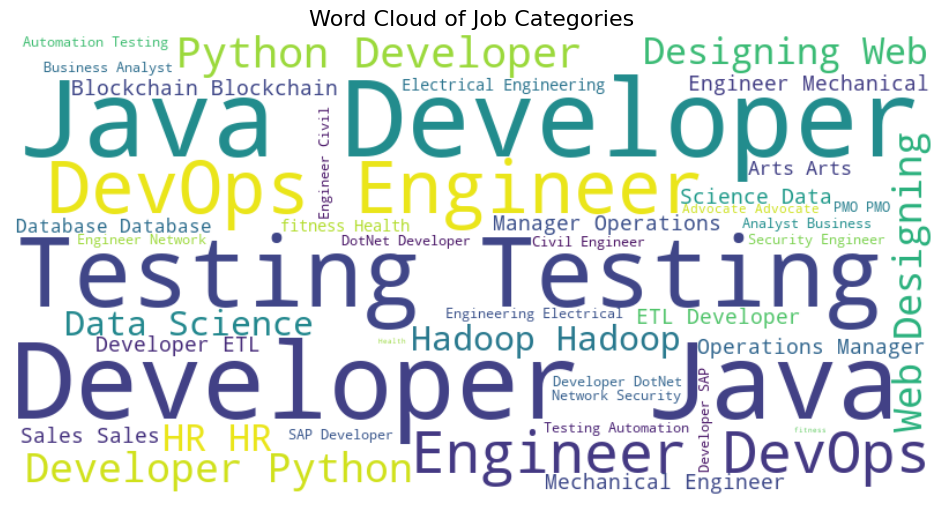

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# WordCloud ke liye text join kardo (saari categories ek string me)
text = " ".join(df['Category'].astype(str))

# WordCloud generate karo
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

# Plot karo
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Job Categories", fontsize=16)
plt.show()

### Text Cleaning

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [14]:

# Agar first time use kar rahe ho toh ye chala lena
# nltk.download('stopwords')
# nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [21]:
def clean_text(text):
    text=text.lower()  #lowercase
    text=re.sub(r'[^a-zA-Z\s]','',text) #re.sub(pattern,replacement,string )
    words=text.split()
    words=[lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)


In [22]:
# Resume column clean karo
df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

In [23]:
# Check sample
print(df[['Resume', 'Cleaned_Resume']].head())

                                              Resume  \
0  Skills * Programming Languages: Python (pandas...   
1  Education Details \r\nMay 2013 to May 2017 B.E...   
2  Areas of Interest Deep Learning, Control Syste...   
3  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...   
4  Education Details \r\n MCA   YMCAUST,  Faridab...   

                                      Cleaned_Resume  
0  skill programming language python panda numpy ...  
1  education detail may may uitrgpv data scientis...  
2  area interest deep learning control system des...  
3  skill r python sap hana tableau sap hana sql s...  
4  education detail mca ymcaust faridabad haryana...  


### Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
#initialize
tfidf=TfidfVectorizer(max_features=5000)
#top 5000 words
X=tfidf.fit_transform(df['Cleaned_Resume']).toarray() #features
print("shape",X.shape)


shape (962, 5000)


In [ ]:
y=df['Category'] #labels

### Training/Test split

In [26]:
from sklearn.model_selection import train_test_split

#80%training 20%testing 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("training set shape",X_train.shape)
print("testing set shape:",X_test.shape)

training set shape (769, 5000)
testing set shape: (193, 5000)
